# Build .h5mu from data components

.h5mu will be used to distribute the dataset and as inputs for our UMAP explorer apps.

In [1]:
from datetime import date
from scipy.io import mmread

import anndata as ad
import hisepy
import mudata as mu
import os
import pandas as pd
import polars as pl
import scipy.sparse as sparse
import scanpy as sc

In [2]:
if not os.path.isdir('output'):
    os.mkdir('output')

## Helper functions

In [3]:
def read_feat(in_file):
    with open(in_file, "r") as file:
        feat = [line.rstrip() for line in file]
        header = feat.pop(0)
    return feat

In [4]:
def element_id(n = 3):
    import periodictable
    from random import randrange
    rand_el = []
    for i in range(n):
        el = randrange(0,118)
        rand_el.append(periodictable.elements[el].name)
    rand_str = '-'.join(rand_el)
    return rand_str

## Inputs

In [5]:
in_uuids = {
    'cd4_rna': 'e2c8782f-da0a-4255-9e81-9684da2999cf',
    'cd8_rna': '28191894-a932-4c33-9952-8545623d7530',
    'cd4_rna_feat': 'c8e283d1-991a-4c32-8421-110ffef9063d',
    'cd8_rna_feat': '72d0c86e-1370-43cb-91f4-47fc49eee7d9',
    'cd4_adt': '50e1e4d6-c596-44bd-bc37-13a1577b6d60',
    'cd8_adt': 'b79e19dc-d1e2-4967-80b8-9c56f6baccac',
    'cd4_adt_feat': 'c9d894c5-22e0-45a1-a3ac-f185ad08b47d',
    'cd8_adt_feat': 'a9de0d17-6a88-45c8-bff2-1403063b71a8',
    'cd4_meta': '30a6d419-10a7-4d83-bc3b-2b79d48246fe',
    'cd8_meta': 'eec01309-7337-43f5-a307-13f60f050b02',
    'cd4_labels': '1be4dc27-7a59-4c26-a0f6-b4e1a26c16ca',
    'cd8_labels': '4b6e6a79-50f9-4b2b-9393-650e25d3572a'
}

In [6]:
in_files = {}
for k, uuid in in_uuids.items():
    in_files[k] = hisepy.cache_files([uuid])[0]

2026-06-09 14:47:13,066 INFO [hisepy.logging:175] logging 6072 135481991485248 Calling cache_files
2026-06-09 14:47:17,330 INFO [hisepy.logging:208] logging 6072 135481991485248 Finished cache_files, success=True, time_elapsed=2.846s
2026-06-09 14:47:17,331 INFO [hisepy.logging:175] logging 6072 135481991485248 Calling cache_files
2026-06-09 14:47:21,750 INFO [hisepy.logging:208] logging 6072 135481991485248 Finished cache_files, success=True, time_elapsed=2.802s
2026-06-09 14:47:21,751 INFO [hisepy.logging:175] logging 6072 135481991485248 Calling cache_files
2026-06-09 14:47:25,771 INFO [hisepy.logging:208] logging 6072 135481991485248 Finished cache_files, success=True, time_elapsed=2.531s
2026-06-09 14:47:25,772 INFO [hisepy.logging:175] logging 6072 135481991485248 Calling cache_files
2026-06-09 14:47:29,843 INFO [hisepy.logging:208] logging 6072 135481991485248 Finished cache_files, success=True, time_elapsed=2.641s
2026-06-09 14:47:29,844 INFO [hisepy.logging:175] logging 6072 1

## RNA

In [7]:
cd4_rna_mat = mmread(in_files['cd4_rna']).astype('uint16').transpose()
cd8_rna_mat = mmread(in_files['cd8_rna']).astype('uint16').transpose()

In [8]:
cd4_rna_feat = read_feat(in_files['cd4_rna_feat'])
cd8_rna_feat = read_feat(in_files['cd8_rna_feat'])

Check if features are the same and in the same order

In [9]:
cd4_rna_feat == cd8_rna_feat

True

In [10]:
cd4_rna_mat = cd4_rna_mat.tocsr()
cd8_rna_mat = cd8_rna_mat.tocsr()

In [11]:
rna_mat = sparse.vstack([cd4_rna_mat, cd8_rna_mat])

In [12]:
rna_mat

<Compressed Sparse Row sparse matrix of dtype 'uint16'
	with 251719003 stored elements and shape (147414, 36601)>

## ADT

In [13]:
cd4_adt_mat = mmread(in_files['cd4_adt']).astype('uint16').transpose()
cd8_adt_mat = mmread(in_files['cd8_adt']).astype('uint16').transpose()

In [14]:
cd4_adt_feat = read_feat(in_files['cd4_adt_feat'])
cd8_adt_feat = read_feat(in_files['cd8_adt_feat'])

Check if features are the same and in the same order

In [15]:
cd4_adt_feat == cd8_adt_feat

True

In [16]:
cd4_adt_mat = cd4_adt_mat.tocsr()
cd8_adt_mat = cd8_adt_mat.tocsr()

In [17]:
adt_mat = sparse.vstack([cd4_adt_mat, cd8_adt_mat])

In [18]:
adt_mat

<Compressed Sparse Row sparse matrix of dtype 'uint16'
	with 7497552 stored elements and shape (147414, 55)>

## Metadata and labels

In [19]:
cd4_meta = pl.read_csv(in_files['cd4_meta'])
cd8_meta = pl.read_csv(in_files['cd8_meta'])

In [20]:
meta = pl.concat([cd4_meta, cd8_meta])

In [21]:
meta.shape

(147414, 33)

In [22]:
meta.head()

orig.ident,nCount_RNA,nFeature_RNA,barcodes,adt_umis,batch_id,pool_id,chip_id,well_id,pbmc_sample_id,treatment,timepoint,n_reads,n_umis,n_genes,n_mito_umis,frac_mito_umis,original_barcodes,hto_barcode,hto_category,Sample,archr_name,n_fragments,n_unique,n_mito,frac_mito,RNA_snn_res.0.8,nCount_ADT,nFeature_ADT,treat_time,CD4pos,CD8pos,CD4_CD8
str,i64,i64,str,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,str,str,str,str,str,i64,i64,i64,f64,i64,i64,i64,str,bool,bool,str
"""SeuratProject""",4974,2157,"""2da9d348fb8111eda35df29f570c07…",1746,"""EXP-00454""","""EXP-00454-P1""","""EXP-00454-P1C1""","""EXP-00454-P1C1W1""","""PC02184-044""","""dmso""",24,19938,4974,2157,363,0.072979,"""AAACAGCCATAGTCAT""","""TGTCTTTCCTGCCAG""","""singlet""","""EXP-00454-P1_PC02184-044""","""EXP-00454-P1_PC02184-044#2da9d…",34495,9268,0,0.0,2,1746,49,"""dmso_24""",true,false,"""t_cd4"""
"""SeuratProject""",4511,2134,"""2daec6d2fb8111eda35df29f570c07…",1506,"""EXP-00454""","""EXP-00454-P1""","""EXP-00454-P1C1""","""EXP-00454-P1C1W1""","""PC02184-044""","""dmso""",24,18049,4511,2134,161,0.035691,"""AAACCAACAGCTCATA""","""TGTCTTTCCTGCCAG""","""singlet""","""EXP-00454-P1_PC02184-044""","""EXP-00454-P1_PC02184-044#2daec…",46483,12593,0,0.0,2,1506,49,"""dmso_24""",true,false,"""t_cd4"""
"""SeuratProject""",4289,2091,"""2db119d2fb8111eda35df29f570c07…",1661,"""EXP-00454""","""EXP-00454-P1""","""EXP-00454-P1C1""","""EXP-00454-P1C1W1""","""PC02184-044""","""dmso""",24,17502,4289,2091,302,0.070413,"""AAACCGAAGGAAGCAC""","""TGTCTTTCCTGCCAG""","""singlet""","""EXP-00454-P1_PC02184-044""","""EXP-00454-P1_PC02184-044#2db11…",46164,12514,1,0.000022,3,1661,50,"""dmso_24""",true,false,"""t_cd4"""
"""SeuratProject""",2904,1560,"""2db582c4fb8111eda35df29f570c07…",1400,"""EXP-00454""","""EXP-00454-P1""","""EXP-00454-P1C1""","""EXP-00454-P1C1W1""","""PC02184-044""","""dmso""",24,11174,2904,1560,179,0.061639,"""AAACCGCGTTGGCCGA""","""TGTCTTTCCTGCCAG""","""singlet""","""EXP-00454-P1_PC02184-044""","""EXP-00454-P1_PC02184-044#2db58…",40753,10348,10,0.000245,12,1400,49,"""dmso_24""",true,false,"""t_cd4"""
"""SeuratProject""",3500,1867,"""2db6727efb8111eda35df29f570c07…",1657,"""EXP-00454""","""EXP-00454-P1""","""EXP-00454-P1C1""","""EXP-00454-P1C1W1""","""PC02184-044""","""dmso""",24,14753,3500,1867,315,0.09,"""AAACCGGCAGCTCAAC""","""TGTCTTTCCTGCCAG""","""singlet""","""EXP-00454-P1_PC02184-044""","""EXP-00454-P1_PC02184-044#2db67…",42251,10834,178,0.004213,2,1657,49,"""dmso_24""",true,false,"""t_cd4"""


In [23]:
cd4_labels = pl.read_csv(in_files['cd4_labels'], infer_schema_length=100000)
cd8_labels = pl.read_csv(in_files['cd8_labels'], infer_schema_length=100000)

In [24]:
labels = pl.concat([cd4_labels, cd8_labels])

In [25]:
labels.shape

(147414, 10)

In [26]:
labels = labels.drop(['treatment', 'timepoint'])

In [27]:
meta = meta.join(
    labels,
    how = 'left',
    on = 'barcodes'
)

In [28]:
meta.shape

(147414, 40)

In [29]:
meta = meta.drop(
    ['orig.ident', 'nCount_RNA', 'nFeature_RNA']
)

## Colorsets and label updates

In [30]:
timepoint_colors = pl.read_csv('../common/color_sets/timepoint_colors.csv')
treatment_colors = pl.read_csv('../common/color_sets/treatment_colors.csv')
treat_time_colors = pl.read_csv('../common/color_sets/treat_time_colors.csv')
aifi_cell_type_colors = pl.read_csv('../common/color_sets/aifi_cell_type_colors.csv')

In [31]:
timepoint_label_dict = dict(zip(timepoint_colors['timepoint'], timepoint_colors['timepoint_label']))
timepoint_color_dict = dict(zip(timepoint_colors['timepoint_label'], timepoint_colors['timepoint_color']))

In [32]:
treatment_label_dict = dict(zip(treatment_colors['treatment'], treatment_colors['treatment_label']))
treatment_color_dict = dict(zip(treatment_colors['treatment_label'], treatment_colors['treatment_color']))

In [33]:
treat_time_color_dict = dict(zip(treat_time_colors['treat_time'], treat_time_colors['treat_color']))

In [34]:
aifi_cell_type_label_dict = dict(zip(aifi_cell_type_colors['aifi_cell_type'], aifi_cell_type_colors['cell_type_label']))
aifi_cell_type_color_dict = dict(zip(aifi_cell_type_colors['cell_type_label'], aifi_cell_type_colors['cell_type_color']))

In [35]:
meta = meta.with_columns(
    pl.Series(
        name = 'Cell Type',
        values = [aifi_cell_type_label_dict[x] for x in meta['aifi_cell_type']]
    ),
    pl.Series(
        name = 'Timepoint',
        values = [timepoint_label_dict[x] for x in meta['timepoint']]
    ),
    pl.Series(
        name = 'Treatment',
        values = [treatment_label_dict[x] for x in meta['treatment']]
    )
)

In [36]:
keep_cols = {
    'barcodes': 'barcodes',
    'pbmc_sample_id': 'specimen.specimenGuid',
    'batch_id': 'batch_id',
    'pool_id': 'pool_id',
    'chip_id': 'chip_id',
    'well_id': 'well_id',
    'Treatment': 'Treatment',
    'Timepoint': 'Timepoint',
    'Cell Type': 'Cell Type',
    'n_reads': 'rna.n_reads',
    'n_umis': 'rna.n_umis',
    'n_mito_umis': 'rna.n_mito_umis',
    'frac_mito_umis': 'rna.frac_mito_umis',
    'n_genes': 'rna.n_genes',
    'adt_umis': 'adt.n_umis',
    'n_fragments': 'atac.n_fragments',
    'n_unique': 'atac.n_unique',
    'n_mito': 'atac.n_mito',
    'frac_mito': 'atac.frac_mito'
}

In [37]:
obs = meta.select(keep_cols.keys()).rename(keep_cols)

In [38]:
obs.columns

['barcodes',
 'specimen.specimenGuid',
 'batch_id',
 'pool_id',
 'chip_id',
 'well_id',
 'Treatment',
 'Timepoint',
 'Cell Type',
 'rna.n_reads',
 'rna.n_umis',
 'rna.n_mito_umis',
 'rna.frac_mito_umis',
 'rna.n_genes',
 'adt.n_umis',
 'atac.n_fragments',
 'atac.n_unique',
 'atac.n_mito',
 'atac.frac_mito']

In [39]:
obs = obs.to_pandas()
obs = obs.set_index('barcodes')

### Convert categorical columns

In [40]:
cats = ['specimen.specimenGuid', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'Treatment', 'Timepoint', 'Cell Type']
for cat in cats:
    obs[cat] = obs[cat].astype('category')

In [41]:
obs.head()

,specimen.specimenGuid,batch_id,pool_id,chip_id,well_id,Treatment,Timepoint,Cell Type,rna.n_reads,rna.n_umis,rna.n_mito_umis,rna.frac_mito_umis,rna.n_genes,adt.n_umis,atac.n_fragments,atac.n_unique,atac.n_mito,atac.frac_mito
barcodes,,,,,,,,,,,,,,,,,,
2da9d348fb8111eda35df29f570c0793,PC02184-044,EXP-00454,EXP-00454-P1,EXP-00454-P1C1,EXP-00454-P1C1W1,DMSO,T24,CD4 Naive,19938,4974,363,0.072979,2157,1746,34495,9268,0,0.000000
2daec6d2fb8111eda35df29f570c0793,PC02184-044,EXP-00454,EXP-00454-P1,EXP-00454-P1C1,EXP-00454-P1C1W1,DMSO,T24,CD4 Naive,18049,4511,161,0.035691,2134,1506,46483,12593,0,0.000000
2db119d2fb8111eda35df29f570c0793,PC02184-044,EXP-00454,EXP-00454-P1,EXP-00454-P1C1,EXP-00454-P1C1W1,DMSO,T24,CD4 Naive,17502,4289,302,0.070413,2091,1661,46164,12514,1,0.000022
2db582c4fb8111eda35df29f570c0793,PC02184-044,EXP-00454,EXP-00454-P1,EXP-00454-P1C1,EXP-00454-P1C1W1,DMSO,T24,CD4 Naive,11174,2904,179,0.061639,1560,1400,40753,10348,10,0.000245
2db6727efb8111eda35df29f570c0793,PC02184-044,EXP-00454,EXP-00454-P1,EXP-00454-P1C1,EXP-00454-P1C1W1,DMSO,T24,CD4 Naive,14753,3500,315,0.090000,1867,1657,42251,10834,178,0.004213


## Make MuData object

In [42]:
rna_adata = ad.AnnData(
    X = rna_mat
)
rna_adata.var_names = cd4_rna_feat
adt_adata = ad.AnnData(
    X = adt_mat
)
adt_adata.var_names = cd4_adt_feat

In [43]:
rna_adata

AnnData object with n_obs × n_vars = 147414 × 36601

In [44]:
mudata = mu.MuData(
    {
        'rna': rna_adata,
        'adt': adt_adata
    }
)

/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/mudata/_core/mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_up

In [45]:
mudata.obs = obs

In [46]:
mudata

MuData object with n_obs × n_vars = 147414 × 36656
  obs:	'specimen.specimenGuid', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'Treatment', 'Timepoint', 'Cell Type', 'rna.n_reads', 'rna.n_umis', 'rna.n_mito_umis', 'rna.frac_mito_umis', 'rna.n_genes', 'adt.n_umis', 'atac.n_fragments', 'atac.n_unique', 'atac.n_mito', 'atac.frac_mito'
  2 modalities
    rna:	147414 × 36601
    adt:	147414 × 55

### Add colorsets to the mudata object

In [47]:
mudata.uns['Cell Type_colors'] = [aifi_cell_type_color_dict[x] for x in obs['Cell Type'].cat.categories]
mudata.uns['Treatment_colors'] = [treatment_color_dict[x] for x in obs['Treatment'].cat.categories]
mudata.uns['Timepoint_colors'] = [timepoint_color_dict[x] for x in obs['Timepoint'].cat.categories]

### Save full mudata object

In [48]:
out_full = 'output/tcell-vrd_all_labeled_data_{d}.h5mu'.format(d = date.today())
mudata.write_h5mu(out_full)

/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


### Split into time points and add UMAP coordinates

In [49]:
umap_uuids = {
    '4h': '6b839963-4455-4df9-9ff8-cf1a06a4535f',
    '24h': '4ea7d50e-6499-4833-863b-c019d4715f0d',
    '72h': '49e869fb-952f-4927-a7b4-ad13fbcd017d'
}

In [50]:
umap_files = {}
for k, uuid in umap_uuids.items():
    umap_files[k] = hisepy.cache_files([uuid])[0]

2026-06-09 14:48:57,557 INFO [hisepy.logging:175] logging 6072 135481991485248 Calling cache_files
2026-06-09 14:49:01,821 INFO [hisepy.logging:208] logging 6072 135481991485248 Finished cache_files, success=True, time_elapsed=2.721s
2026-06-09 14:49:01,822 INFO [hisepy.logging:175] logging 6072 135481991485248 Calling cache_files
2026-06-09 14:49:05,865 INFO [hisepy.logging:208] logging 6072 135481991485248 Finished cache_files, success=True, time_elapsed=2.613s
2026-06-09 14:49:05,867 INFO [hisepy.logging:175] logging 6072 135481991485248 Calling cache_files
2026-06-09 14:49:09,724 INFO [hisepy.logging:208] logging 6072 135481991485248 Finished cache_files, success=True, time_elapsed=2.487s


In [51]:
umap_coords = {}
for k, f in umap_files.items():
    umap_coords[k] = pl.read_csv(f)

In [52]:
umap_coords['4h'].head()

,barcodes,treatment,timepoint,aifi_cell_type,UMAP_1,UMAP_2,cell_type_color,treatment_color
i64,str,str,i64,str,f64,f64,str,str
1,"""46059f68fb7b11ed933dc6f18f77c1…","""bortezomib""",4,"""t_cd4_naive""",0.750592,-2.013244,"""#93A7D1""","""#FF9F45"""
2,"""99cab48afb8011edb519365d129239…","""bortezomib""",4,"""t_cd4_naive""",-2.637212,-3.222115,"""#93A7D1""","""#FF9F45"""
3,"""ccc6bb4afb7b11ed8d7c62b1232be9…","""bortezomib""",4,"""t_cd4_cm""",-4.429662,-0.90911,"""#00AEEF""","""#FF9F45"""
4,"""2f0d7cf6fb8311ed9fae72654f8391…","""bortezomib""",4,"""t_cd8_naive""",6.090755,-0.999125,"""#8DC63F""","""#FF9F45"""
5,"""18a4477cfb8011ed8e8a7625f34dfd…","""bortezomib""",4,"""t_cd4_naive""",-1.178789,-0.92227,"""#93A7D1""","""#FF9F45"""


In [53]:
timepoint_mudata = {}
for k, umap_df in umap_coords.items():
    time_mu = mudata[umap_df['barcodes'].to_list()]
    time_obs = time_mu.obs.copy()
    time_umap = umap_df[['UMAP_1','UMAP_2']].to_numpy()
    time_mu.obsm['X_umap'] = time_umap
    time_mu.obs = time_obs
    timepoint_mudata[k] = time_mu

/tmp/ipykernel_6072/2302215090.py:6: ImplicitModificationWarning: Setting element `.obsm['X_umap']` of view, initializing view as actual.
  time_mu.obsm['X_umap'] = time_umap
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/mudata/_core/mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-package

In [54]:
timepoint_mudata['24h'].obs

,specimen.specimenGuid,batch_id,pool_id,chip_id,well_id,Treatment,Timepoint,Cell Type,rna.n_reads,rna.n_umis,rna.n_mito_umis,rna.frac_mito_umis,rna.n_genes,adt.n_umis,atac.n_fragments,atac.n_unique,atac.n_mito,atac.frac_mito
barcodes,,,,,,,,,,,,,,,,,,
fb079c46fb7f11ed898e2a71e2203848,PC02184-043,EXP-00454,EXP-00454-P1,EXP-00454-P1C1,EXP-00454-P1C1W3,Bortezomib,T24,CD4 CM,7061,3252,191,0.058733,1804,1473,40749,12474,540,0.013252
d4b86298fb8711edbbcffe1e90e63656,PC02184-043,EXP-00454,EXP-00454-P1,EXP-00454-P1C2,EXP-00454-P1C2W1,Bortezomib,T24,CD4 Naive,12495,3001,228,0.075975,1683,1718,45553,12545,77,0.001690
c121af4cfb8111edb32712c42668f295,PC02184-043,EXP-00454,EXP-00454-P1,EXP-00454-P1C2,EXP-00454-P1C2W6,Bortezomib,T24,CD4 Naive,17578,3666,195,0.053191,1828,2110,28556,6811,51,0.001786
b5ae8ff2fb7e11ed84ffaefa3cccb57a,PC02184-043,EXP-00454,EXP-00454-P1,EXP-00454-P1C2,EXP-00454-P1C2W8,Bortezomib,T24,CD8 Naive,20344,4119,225,0.054625,2082,2841,34610,9370,8,0.000231
c64971c6fb8111edb32712c42668f295,PC02184-043,EXP-00454,EXP-00454-P1,EXP-00454-P1C2,EXP-00454-P1C2W6,Bortezomib,T24,CD8 Memory,18351,3403,435,0.127828,1766,2081,42981,10103,3,0.000070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ec688326fb7f11ed898e2a71e2203848,PC02184-042,EXP-00454,EXP-00454-P1,EXP-00454-P1C1,EXP-00454-P1C1W3,Lenalidomide,T24,CD4 CM,6118,2775,160,0.057658,1552,1120,45365,14164,38,0.000838
49fd91b6fb7b11ed933dc6f18f77c1a7,PC02184-042,EXP-00454,EXP-00454-P1,EXP-00454-P1C2,EXP-00454-P1C2W7,Lenalidomide,T24,CD4 CM,19898,2961,153,0.051672,1522,1821,64479,10508,0,0.000000
1d4412e4fb8011ed8e8a7625f34dfd6b,PC02184-042,EXP-00454,EXP-00454-P1,EXP-00454-P1C2,EXP-00454-P1C2W5,Lenalidomide,T24,CD4 CM,13335,3246,271,0.083487,1671,2533,33457,8399,0,0.000000


/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
  values = adata.obs_vector(value_to_plot, layer=layer)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
  values = adata.obs_vector(value_to_plot, layer=layer)


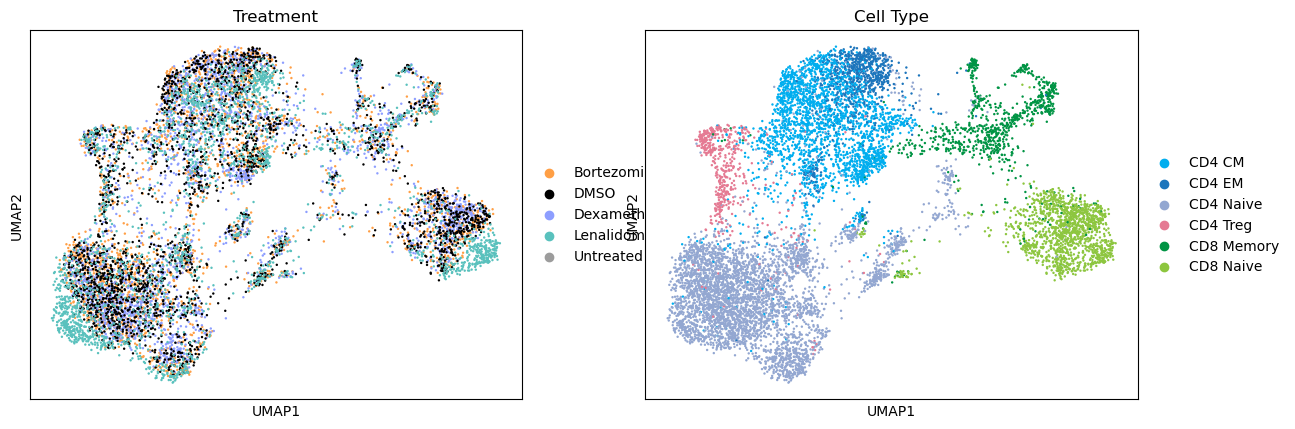

In [55]:
sc.pl.umap(timepoint_mudata['4h'], 
           color = ['Treatment', 'Cell Type'])

/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
  values = adata.obs_vector(value_to_plot, layer=layer)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
  values = adata.obs_vector(value_to_plot, layer=layer)


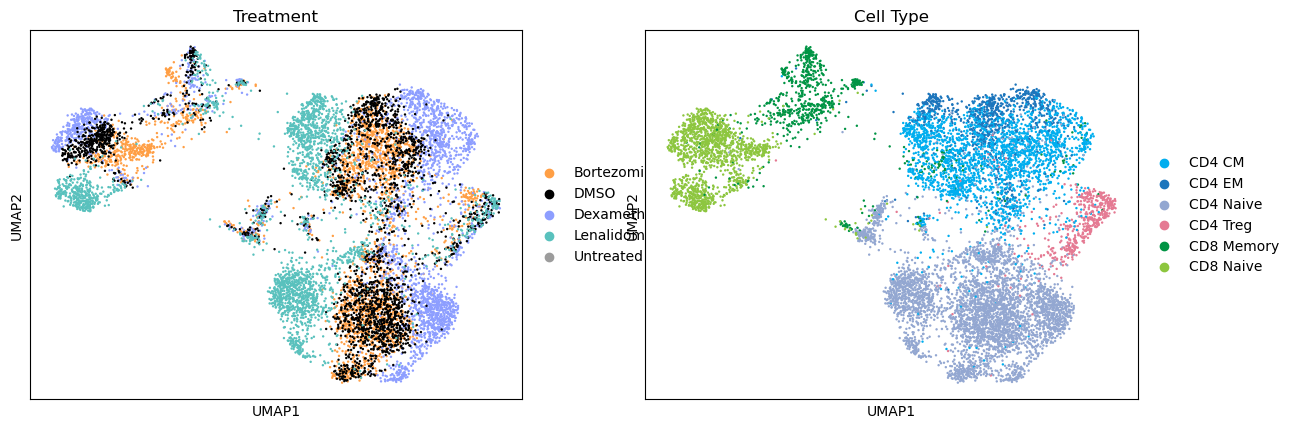

In [56]:
sc.pl.umap(timepoint_mudata['24h'], 
           color = ['Treatment', 'Cell Type'])

/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
  values = adata.obs_vector(value_to_plot, layer=layer)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/scanpy/plotting/_tools/scatterplots.py:1227: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
  values = adata.obs_vector(value_to_plot, layer=layer)


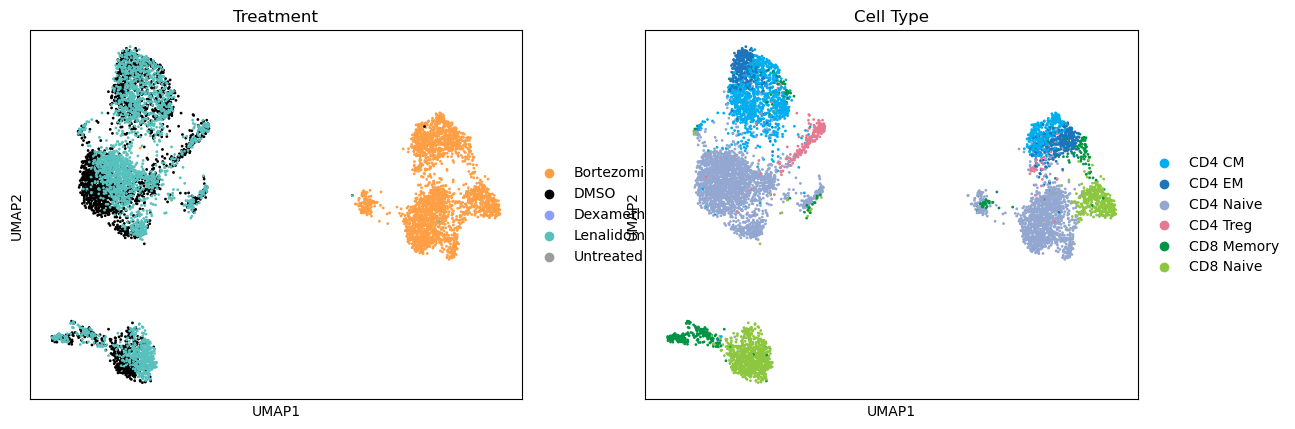

In [57]:
sc.pl.umap(timepoint_mudata['72h'], 
           color = ['Treatment', 'Cell Type'])

### Save time point mudata objects

In [58]:
out_4h = 'output/tcell-vrd_4h_sampled_subset_{d}.h5mu'.format(d = date.today())
timepoint_mudata['4h'].write_h5mu(out_4h)
out_24h = 'output/tcell-vrd_24h_sampled_subset_{d}.h5mu'.format(d = date.today())
timepoint_mudata['24h'].write_h5mu(out_24h)
out_72h = 'output/tcell-vrd_72h_sampled_subset_{d}.h5mu'.format(d = date.today())
timepoint_mudata['72h'].write_h5mu(out_72h)

/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/mudata/_core/mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_up

## Upload results to HISE

In [59]:
study_space_uuid = '40df6403-29f0-4b45-ab7d-f46d420c422e'
title = 'VRd TEA-seq TE .h5mu files {d}'.format(d = date.today())

In [61]:
search_id = element_id()
search_id

'zinc-carbon-bismuth'

In [62]:
in_files = list(in_uuids.values()) + list(umap_uuids.values())

In [63]:
in_files

['e2c8782f-da0a-4255-9e81-9684da2999cf',
 '28191894-a932-4c33-9952-8545623d7530',
 'c8e283d1-991a-4c32-8421-110ffef9063d',
 '72d0c86e-1370-43cb-91f4-47fc49eee7d9',
 '50e1e4d6-c596-44bd-bc37-13a1577b6d60',
 'b79e19dc-d1e2-4967-80b8-9c56f6baccac',
 'c9d894c5-22e0-45a1-a3ac-f185ad08b47d',
 'a9de0d17-6a88-45c8-bff2-1403063b71a8',
 '30a6d419-10a7-4d83-bc3b-2b79d48246fe',
 'eec01309-7337-43f5-a307-13f60f050b02',
 '1be4dc27-7a59-4c26-a0f6-b4e1a26c16ca',
 '4b6e6a79-50f9-4b2b-9393-650e25d3572a',
 '6b839963-4455-4df9-9ff8-cf1a06a4535f',
 '4ea7d50e-6499-4833-863b-c019d4715f0d',
 '49e869fb-952f-4927-a7b4-ad13fbcd017d']

In [64]:
out_files = [out_full, out_4h, out_24h, out_72h]
out_files

['output/tcell-vrd_all_labeled_data_2026-06-09.h5mu',
 'output/tcell-vrd_4h_sampled_subset_2026-06-09.h5mu',
 'output/tcell-vrd_24h_sampled_subset_2026-06-09.h5mu',
 'output/tcell-vrd_72h_sampled_subset_2026-06-09.h5mu']

In [66]:
import session_info
session_info.show()

/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  mod_version = _find_version(mod.__version__)
/home/workspace/environment/archrpixiv11/.pixi/envs/default/lib/python3.13/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)


In [67]:
hisepy.upload_files(
    files = out_files,
    study_space_id = study_space_uuid,
    title = title,
    input_file_ids = in_files,
    destination = search_id
)

2026-06-09 14:49:49,545 INFO [hisepy.logging:175] logging 6072 135481991485248 Calling upload_files


Please provide input of comma separated sample ids for the files being uploaded. If you do not have any sample ids, press enter:  


2026-06-09 14:49:56,040 INFO [hisepy.logging:175] logging 6072 135481991485248 Calling get_default_store
2026-06-09 14:49:57,802 INFO [hisepy.logging:208] logging 6072 135481991485248 Finished get_default_store, success=True, time_elapsed=0.357s
2026-06-09 14:50:21,625 INFO [hisepy.logging:208] logging 6072 135481991485248 Finished upload_files, success=True, time_elapsed=29.314s


{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': 'eeba22b5-79d4-4637-8af8-44ed6c091020',
 'ProcessId': '9715d99e-a7bd-4a91-857e-cbb52358546c',
 'WorkflowId': 'b10ae7ea-7b65-40e2-b297-ece7972fd41d',
 'FileIds': ['5db74e6c-6eb4-4f76-82da-8eb0e98f3d72',
  '61443236-7420-4ca2-b035-0e01855081e2',
  '594f9f53-4859-46d0-9ae5-82ec3074df84',
  'c17a609e-ea3c-4265-bb53-986946b4eb2c']}